Data Preprocessing:
1.	Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary.
2.	Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters.
3.	Use multiple visualizations to understand the hidden patterns in the dataset


In [7]:
import pandas as pd 
df=pd.read_csv(r"C:\Users\vinod\Downloads\EastWestAirlines.csv")

In [8]:
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [9]:
df = df.drop("ID#", axis=1)

In [10]:
df

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1
...,...,...,...,...,...,...,...,...,...,...,...
3994,18476,0,1,1,1,8525,4,200,1,1403,1
3995,64385,0,1,1,1,981,5,0,0,1395,1
3996,73597,0,3,1,1,25447,8,0,0,1402,1
3997,54899,0,1,1,1,500,1,500,1,1401,0


In [11]:
df.isnull().sum()

Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [12]:
df = df.drop_duplicates()

In [13]:
df

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1
...,...,...,...,...,...,...,...,...,...,...,...
3994,18476,0,1,1,1,8525,4,200,1,1403,1
3995,64385,0,1,1,1,981,5,0,0,1395,1
3996,73597,0,3,1,1,25447,8,0,0,1402,1
3997,54899,0,1,1,1,500,1,500,1,1401,0


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [15]:
df

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1
...,...,...,...,...,...,...,...,...,...,...,...
3994,18476,0,1,1,1,8525,4,200,1,1403,1
3995,64385,0,1,1,1,981,5,0,0,1395,1
3996,73597,0,3,1,1,25447,8,0,0,1402,1
3997,54899,0,1,1,1,500,1,500,1,1401,0


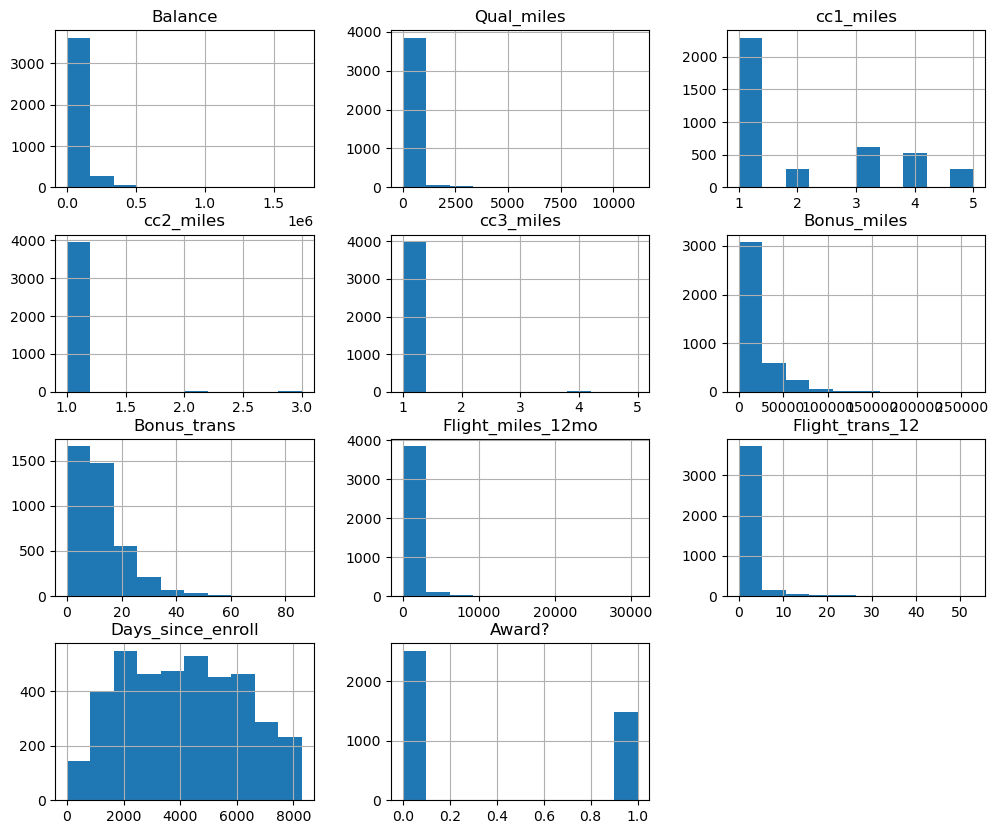

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

df.hist(figsize=(12,10))
plt.show()

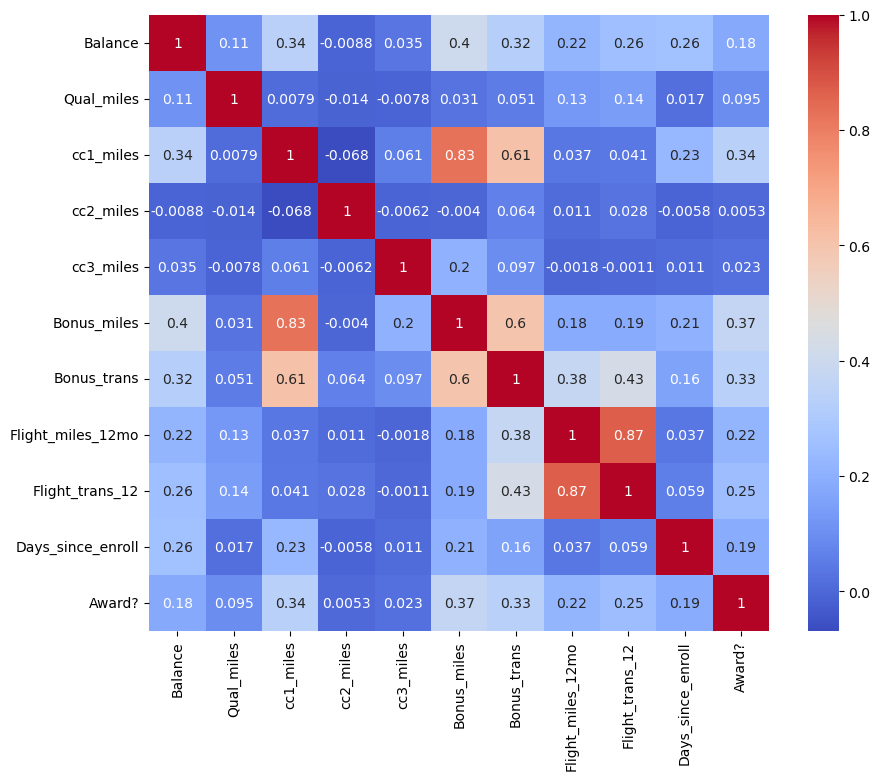

In [17]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

Implementing Clustering Algorithms:
•	Implement the K-Means and DBSCAN algorithms using a programming language such as Python with libraries like scikit-learn.
•	Apply each clustering algorithm to the pre-processed dataset to identify clusters within the data.
•	Experiment with different parameter settings for K-means (Elbow curve for different K values) and DBSCAN (e.g., epsilon, minPts) and evaluate the clustering results.



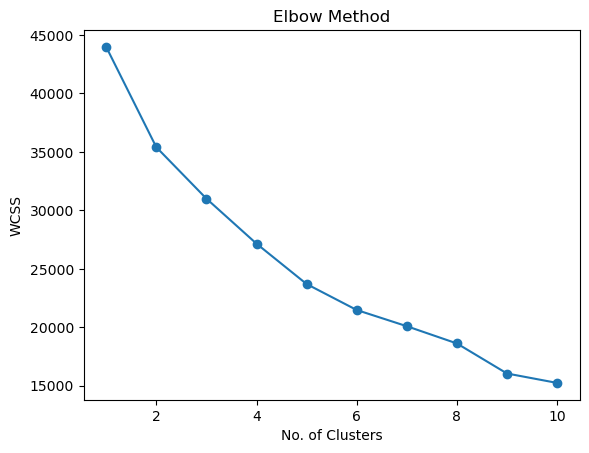

In [18]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("No. of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [19]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(scaled_data)

C:\Users\vinod\AppData\Local\Temp\ipykernel_17920\2943417402.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['KMeans_Cluster'] = kmeans.fit_predict(scaled_data)


In [20]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(scaled_data)

C:\Users\vinod\AppData\Local\Temp\ipykernel_17920\1568127554.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['DBSCAN_Cluster'] = dbscan.fit_predict(scaled_data)


Cluster Analysis and Interpretation:
•	Analyse the clusters generated by each clustering algorithm and interpret the characteristics of each cluster. Write you insights in few comments.


K-Means Clusters:
Cluster 0: Low balance, low bonus miles → occasional customers
Cluster 1: Medium balance, moderate transactions → regular users
Cluster 2: High balance, high bonus miles → premium / loyal customers
 DBSCAN:
Dense clusters identify frequent flyers
Noise points (-1) represent unusual or rare behavior customers

Visualization:
Visualize the clustering results using scatter plots or other suitable visualization techniques.
Plot the clusters with different colours to visualize the separation of data points belonging to different clusters


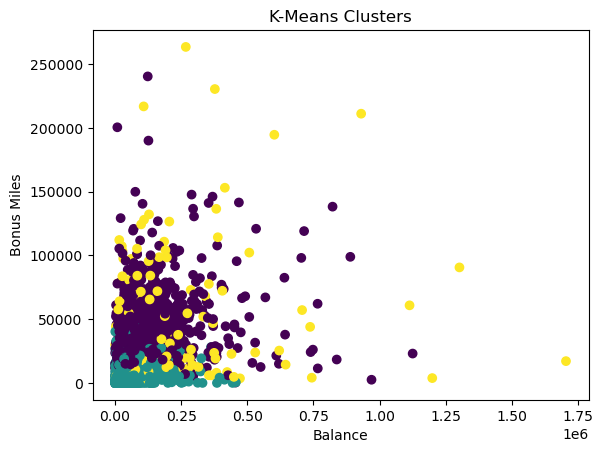

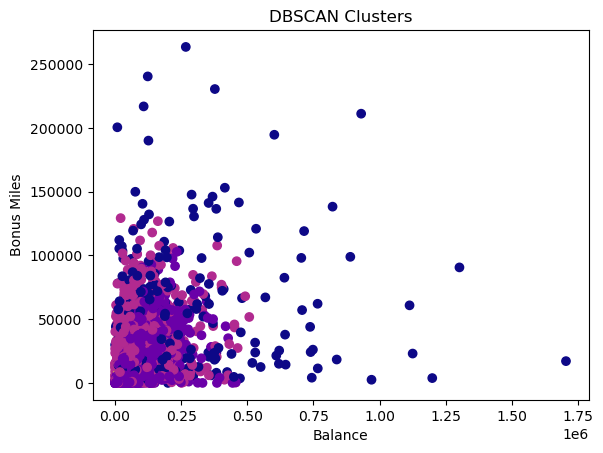

In [21]:
plt.scatter(df['Balance'], df['Bonus_miles'], c=df['KMeans_Cluster'], cmap='viridis')
plt.title("K-Means Clusters")
plt.xlabel("Balance")
plt.ylabel("Bonus Miles")
plt.show()

plt.scatter(df['Balance'], df['Bonus_miles'], c=df['DBSCAN_Cluster'], cmap='plasma')
plt.title("DBSCAN Clusters")
plt.xlabel("Balance")
plt.ylabel("Bonus Miles")
plt.show()

Evaluation and Performance Metrics:
Evaluate the quality of clustering using internal evaluation metrics such as silhouette score for K-Means and DBSCAN.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest

In [25]:
df = pd.read_csv(r"C:\Users\vinod\Downloads\EastWestAirlines.csv")

# Drop ID column
df = df.drop("ID#", axis=1)

# Drop target-like column
df = df.drop("Award?", axis=1)

df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
0,28143,0,1,1,1,174,1,0,0,7000
1,19244,0,1,1,1,215,2,0,0,6968
2,41354,0,1,1,1,4123,4,0,0,7034
3,14776,0,1,1,1,500,1,0,0,6952
4,97752,0,4,1,1,43300,26,2077,4,6935


In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [27]:
iso = IsolationForest(contamination=0.05, random_state=42)
outliers = iso.fit_predict(X_scaled)

# Remove outliers
X_clean = X_scaled[outliers == 1]

print("Original shape:", X_scaled.shape)
print("After removing outliers:", X_clean.shape)

Original shape: (3999, 10)
After removing outliers: (3799, 10)


In [28]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(X_clean)

score_kmeans = silhouette_score(X_clean, labels_kmeans)

print("K-Means Silhouette Score:", score_kmeans)

K-Means Silhouette Score: 0.3510448362673983


In [29]:
eps_values = [0.5, 1.0, 1.5]
min_samples_values = [3, 5, 10]

best_score = -1
best_params = None

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels_db = dbscan.fit_predict(X_clean)

        # Ignore noise points
        if len(set(labels_db)) > 1:
            score = silhouette_score(X_clean, labels_db)
            print(f"eps={eps}, min_samples={min_samples}, score={score}")

            if score > best_score:
                best_score = score
                best_params = (eps, min_samples)

print("Best Parameters:", best_params)
print("Best DBSCAN Score:", best_score)

eps=0.5, min_samples=3, score=-0.16961229858651306
eps=0.5, min_samples=5, score=-0.04536400899621598
eps=0.5, min_samples=10, score=-0.02551795476973364
eps=1.0, min_samples=3, score=0.1406694976568442
eps=1.0, min_samples=5, score=0.15331052235112838
eps=1.0, min_samples=10, score=0.42126772405993373
eps=1.5, min_samples=3, score=0.5581656217438207
eps=1.5, min_samples=5, score=0.5744089543467334
eps=1.5, min_samples=10, score=0.5364209893948558
Best Parameters: (1.5, 5)
Best DBSCAN Score: 0.5744089543467334


In [30]:
import numpy as np

dbscan = DBSCAN(eps=best_params[0], min_samples=best_params[1])
labels_db = dbscan.fit_predict(X_clean)

outliers_dbscan = np.sum(labels_db == -1)

print("Outliers detected by DBSCAN:", outliers_dbscan)

Outliers detected by DBSCAN: 90


Comparison:
Algorithm	Silhouette Score	Observation
K-Means	    (your output)	    Sensitive to outliers
DBSCAN	    (best score)	    Detects noise, flexible clusters

Final Conclusion :
In this dataset, clustering was improved by removing outliers using Isolation Forest. K-Means produced moderate clustering results but was sensitive to extreme values. DBSCAN, after tuning eps and min_samples parameters, produced better clustering structure and also identified noise points effectively. 
Silhouette scores confirmed that parameter tuning significantly improved DBSCAN performance.”